# Customer and Sales Analysis: Analyzing ERP Sales through the CRISP-DM Framework

# Imports and Install packages/libraries/etc

In [ ]:
import pandas as pd

# Preprocessing

## Small preprocess

Replace missing or empty values with `NULL` before importing into MySQL for further preprocessing
- Remove trailing white spaces
- Replace empty values


### Processing `sales_cut.csv`

In [ ]:
sales_df = pd.read_csv('/content/sales_cut_1m.csv')

print('Null values before replacing:')
display(sales_df.isnull().sum())

# Replace empty strings and NaN with 'NULL'
sales_df = sales_df.fillna('NULL')
sales_df = sales_df.replace(r'^\s*$', 'NULL', regex=True)

print('\nNull values after replacing:')
display(sales_df.isnull().sum())

print('\nFirst 5 rows of processed sales_df:')
display(sales_df.head())

Null values before replacing:


,0
invoice_id,0
customer_id,0
invoice_date,0
product_id,0
quantity,0
revenue,0
store_id,0



Null values after replacing:


,0
invoice_id,0
customer_id,0
invoice_date,0
product_id,0
quantity,0
revenue,0
store_id,0



First 5 rows of processed sales_df:


,invoice_id,customer_id,invoice_date,product_id,quantity,revenue,store_id
0,1-20150105-000001,1,5 01 2015,34,1,0,104
1,1-20150105-000001,1,5 01 2015,64,1,0,104
2,1-20150105-000001,1,5 01 2015,54,1,0,104
3,1-20150209-000002,1,9 02 2015,91,1,0,101
4,1-20150225-000003,1,25 02 2015,69,1,0,108


### Processing `customers.csv`

In [ ]:
customers_df = pd.read_csv('customers.csv')

print('Null values before replacing:')
display(customers_df.isnull().sum())

# Replace empty strings and NaN with 'NULL'
customers_df = customers_df.fillna('NULL')
customers_df = customers_df.replace(r'^\s*$', 'NULL', regex=True)

print('\nNull values after replacing:')
display(customers_df.isnull().sum())

print('\nFirst 5 rows of processed customers_df:')
display(customers_df.head())

Null values before replacing:


,0
customer_id,0
created_at,0
first_name,49855
last_name,199705
email,150373
phone,100029
email_opt_in,0
sms_opt_in,0
call_opt_in,0



Null values after replacing:


,0
customer_id,0
created_at,0
first_name,0
last_name,0
email,0
phone,0
email_opt_in,0
sms_opt_in,0
call_opt_in,0



First 5 rows of processed customers_df:


,customer_id,created_at,first_name,last_name,email,phone,email_opt_in,sms_opt_in,call_opt_in
0,1,2015-01-01,NULL,NULL,james90@example.com,001-635-402-0473x8718,0,1,1
1,2,2015-01-01,Carol,Flores,NULL,(411)842-2979x32290,0,1,1
2,3,2015-01-01,Timothy,NULL,eortega@example.org,798-243-1520,1,1,1
3,4,2015-01-01,Jesus,Parker,npowell@example.com,001-809-533-4388x0836,0,1,0
4,5,2015-01-01,Cindy,Craig,redwards@example.net,NULL,1,0,0


### Processing `items.csv`

In [ ]:
items_df = pd.read_csv('items.csv')

print('Null values before replacing:')
display(items_df.isnull().sum())

# Replace empty strings and NaN with 'NULL'
items_df = items_df.fillna('NULL')
items_df = items_df.replace(r'^\s*$', 'NULL', regex=True)

print('\nNull values after replacing:')
display(items_df.isnull().sum())

print('\nFirst 5 rows of processed items_df:')
display(items_df.head())

Null values before replacing:


,0
product_id,0
product_name,0
brand,0
category,0
gramm_g,23
unit_price,0



Null values after replacing:


,0
product_id,0
product_name,0
brand,0
category,0
gramm_g,0
unit_price,0



First 5 rows of processed items_df:


,product_id,product_name,brand,category,gramm_g,unit_price
0,1,AromaWave Refill Liquid Mint 100,AromaWave,REFILL,100.0,61.5
1,2,Citrus & Co Refill Liquid Pine 100,Citrus & Co,REFILL,100.0,49.0
2,3,BreezeLine Refill Liquid Pine 20,BreezeLine,REFILL,20.0,15.0
3,4,FreshNest Refill Liquid Chocolate 100,FreshNest,REFILL,100.0,61.0
4,5,Citrus & Co Refill Liquid Citrus 10,Citrus & Co,REFILL,10.0,8.0


In [ ]:
items_df['product_name'] = items_df['product_name'].str.lower()
items_df['brand'] = items_df['brand'].str.lower()
items_df['category'] = items_df['category'].str.lower()

print('\nFirst 5 rows of processed items_df with lowercase values:')
display(items_df.head())


First 5 rows of processed items_df with lowercase values:


,product_id,product_name,brand,category,gramm_g,unit_price
0,1,aromawave refill liquid mint 100,aromawave,refill,100.0,61.5
1,2,citrus & co refill liquid pine 100,citrus & co,refill,100.0,49.0
2,3,breezeline refill liquid pine 20,breezeline,refill,20.0,15.0
3,4,freshnest refill liquid chocolate 100,freshnest,refill,100.0,61.0
4,5,citrus & co refill liquid citrus 10,citrus & co,refill,10.0,8.0


### Download files

In [ ]:
sales_df.to_csv('sales_sqlprep.csv', index=False)
customers_df.to_csv('customers_sqlprep.csv', index=False)
items_df.to_csv('items_sqlprep.csv', index=False)

## Final preprocessing

Preprocess CSV files for Python analysis after MySQL preprocessing

In [ ]:
customer_rfm = pd.read_csv('customer_rfm.csv')
transactions = pd.read_csv('transactions.csv')
display(customer_rfm.head())
display(transactions.head())

FileNotFoundError: [Errno 2] No such file or directory: 'customer_rfm.csv'

In [ ]:
# Separate products into their own columns
products_one_hot = transactions['products_bought'].str.get_dummies(sep=', ')
transactions_products = pd.concat([transactions['invoice_id'], products_one_hot], axis=1)

# Display few rows
display(transactions_products.head())

# Data Modeling


## Customer RFM Segmentation Analysis
====================================
Dataset : customer_rfm.csv (5,076 customers)
Columns : customer_id, recency_days, frequency, monetary

Sections:
  1. Load & Inspect Data
  2. Preprocessing (Scaling)
  4. Modeling - K-Means Clustering (k selection + evaluation)
  5. Modeling - Hierarchical Clustering (Agglomerative, Ward linkage)
  6. Model Comparison & Evaluation Metrics
  7. Cluster Profiling & Segment Interpretation
  8. Export Results

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_style("whitegrid")

# ---------------------------------------------------------------
# 1. LOAD & INSPECT DATA
# ---------------------------------------------------------------
df = pd.read_csv("customer_rfm.csv")

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescriptive statistics:\n", df.describe())

Shape: (5076, 4)

Missing values:
 customer_id     0
recency_days    0
frequency       0
monetary        0
dtype: int64

Descriptive statistics:
        customer_id  recency_days    frequency      monetary
count  5076.000000   5076.000000  5076.000000   5076.000000
mean   2567.136722   1433.897557   107.233649   6421.333530
std    1482.520550   1423.453948   103.479069   5686.918001
min       1.000000      0.000000     1.000000     78.000000
25%    1279.750000     30.000000    23.000000   1933.750000
50%    2565.500000   1026.500000    66.000000   4255.750000
75%    3849.250000   2832.000000   158.000000   9361.875000
max    5135.000000   4007.000000   395.000000  28189.000000


In [ ]:

# ---------------------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ---------------------------------------------------------------

# --- 2.1 How are customers distributed by spending? ---
print("\n--- Monetary distribution ---")
print(df["monetary"].describe())
print("Skewness:", df["monetary"].skew())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["recency_days"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Recency Distribution")

sns.histplot(df["frequency"], bins=40, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Frequency Distribution")

sns.histplot(df["monetary"], bins=40, kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Monetary Distribution")
plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150)
plt.close()

# --- 2.2 Are most customers recent or inactive? ---
recent_90 = (df["recency_days"] <= 90).mean() * 100
inactive_365 = (df["recency_days"] > 365).mean() * 100
inactive_730 = (df["recency_days"] > 730).mean() * 100

print(f"\n% active in last 90 days : {recent_90:.2f}%")
print(f"% inactive > 365 days    : {inactive_365:.2f}%")
print(f"% inactive > 730 days    : {inactive_730:.2f}%")

# --- 2.3 Are there outliers? (IQR method) ---
print("\n--- Outlier check (IQR method) ---")
outlier_summary = {}
for col in ["recency_days", "frequency", "monetary"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers
    print(f"{col}: bounds=({lower:.1f}, {upper:.1f}) -> "
          f"{n_outliers} outliers ({n_outliers/len(df)*100:.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["recency_days", "frequency", "monetary"]):
    sns.boxplot(x=df[col], ax=ax, color="lightblue")
    ax.set_title(f"{col} - Boxplot")
plt.tight_layout()
plt.savefig("eda_boxplots.png", dpi=150)
plt.close()

# --- 2.4 Does higher frequency mean higher spending? ---
pearson_r = df["frequency"].corr(df["monetary"])
spearman_r = df["frequency"].corr(df["monetary"], method="spearman")
print(f"\nFrequency vs Monetary -> Pearson r = {pearson_r:.3f}, "
      f"Spearman rho = {spearman_r:.3f}")

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="frequency", y="monetary", alpha=0.4)
plt.title(f"Frequency vs Monetary (r = {pearson_r:.2f})")
plt.tight_layout()
plt.savefig("eda_freq_vs_monetary.png", dpi=150)
plt.close()



--- Monetary distribution ---
count     5076.000000
mean      6421.333530
std       5686.918001
min         78.000000
25%       1933.750000
50%       4255.750000
75%       9361.875000
max      28189.000000
Name: monetary, dtype: float64
Skewness: 1.115326951932646

% active in last 90 days : 33.83%
% inactive > 365 days    : 57.90%
% inactive > 730 days    : 53.25%

--- Outlier check (IQR method) ---
recency_days: bounds=(-4173.0, 7035.0) -> 0 outliers (0.00%)
frequency: bounds=(-179.5, 360.5) -> 51 outliers (1.00%)
monetary: bounds=(-9208.4, 20504.1) -> 110 outliers (2.17%)

Frequency vs Monetary -> Pearson r = 0.980, Spearman rho = 0.983


In [ ]:

# ---------------------------------------------------------------
# 3. PREPROCESSING
# ---------------------------------------------------------------
features = ["recency_days", "frequency", "monetary"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:

# ---------------------------------------------------------------
# 4. K-MEANS CLUSTERING - choose k via evaluation metrics
# ---------------------------------------------------------------
print("\n--- K-Means: evaluating k = 2 to 7 ---")
k_results = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    k_results.append({"k": k, "silhouette": sil, "davies_bouldin": db,
                       "calinski_harabasz": ch, "inertia": km.inertia_})
    print(f"k={k}: silhouette={sil:.3f}, DB={db:.3f}, "
          f"CH={ch:.1f}, inertia={km.inertia_:.1f}")

k_results_df = pd.DataFrame(k_results)
best_k = int(k_results_df.loc[k_results_df["silhouette"].idxmax(), "k"])
print(f"\nBest k by silhouette score: {best_k}")

# Elbow / silhouette plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_results_df["k"], k_results_df["inertia"], marker="o")
axes[0].set_title("Elbow Method (Inertia / WCSS)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_results_df["k"], k_results_df["silhouette"], marker="o", color="green")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig("kmeans_k_selection.png", dpi=150)
plt.close()

# Final K-Means model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

kmeans_metrics = {
    "silhouette": silhouette_score(X_scaled, kmeans_labels),
    "davies_bouldin": davies_bouldin_score(X_scaled, kmeans_labels),
    "calinski_harabasz": calinski_harabasz_score(X_scaled, kmeans_labels),
}



--- K-Means: evaluating k = 2 to 7 ---
k=2: silhouette=0.519, DB=0.720, CH=7514.0, inertia=6138.2
k=3: silhouette=0.537, DB=0.644, CH=11061.3, inertia=2840.6
k=4: silhouette=0.510, DB=0.725, CH=11587.0, inertia=1939.0
k=5: silhouette=0.480, DB=0.704, CH=12087.8, inertia=1445.5
k=6: silhouette=0.488, DB=0.737, CH=12835.8, inertia=1114.9
k=7: silhouette=0.484, DB=0.725, CH=13252.1, inertia=912.6

Best k by silhouette score: 3


In [ ]:
print("\n--- Hierarchical (Ward): evaluating k = 2 to 7 ---")
hier_k_results = []
for k in range(2, 8):
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = hc.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    hier_k_results.append({"k": k, "silhouette": sil, "davies_bouldin": db,
                            "calinski_harabasz": ch})
    print(f"k={k}: silhouette={sil:.3f}, DB={db:.3f}, CH={ch:.1f}")

hier_k_df = pd.DataFrame(hier_k_results)
hier_best_k_sil = int(hier_k_df.loc[hier_k_df["silhouette"].idxmax(), "k"])
hier_best_k_db = int(hier_k_df.loc[hier_k_df["davies_bouldin"].idxmin(), "k"])
print(f"\nHierarchical best k by silhouette: {hier_best_k_sil}")
print(f"Hierarchical best k by Davies-Bouldin: {hier_best_k_db}")



--- Hierarchical (Ward): evaluating k = 2 to 7 ---
k=2: silhouette=0.520, DB=0.695, CH=7031.8
k=3: silhouette=0.511, DB=0.632, CH=9299.1
k=4: silhouette=0.502, DB=0.700, CH=9890.2
k=5: silhouette=0.459, DB=0.763, CH=11088.6
k=6: silhouette=0.475, DB=0.760, CH=11951.6
k=7: silhouette=0.482, DB=0.733, CH=11591.4

Hierarchical best k by silhouette: 2
Hierarchical best k by Davies-Bouldin: 3


In [ ]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
kmeans_metrics = {
    "silhouette": silhouette_score(X_scaled, kmeans_labels),
    "davies_bouldin": davies_bouldin_score(X_scaled, kmeans_labels),
    "calinski_harabasz": calinski_harabasz_score(X_scaled, kmeans_labels),
}

hierarchical_final = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hierarchical_labels = hierarchical_final.fit_predict(X_scaled)
hierarchical_metrics = {
    "silhouette": silhouette_score(X_scaled, hierarchical_labels),
    "davies_bouldin": davies_bouldin_score(X_scaled, hierarchical_labels),
    "calinski_harabasz": calinski_harabasz_score(X_scaled, hierarchical_labels),
}

comparison_df = pd.DataFrame({
    "K-Means": kmeans_metrics,
    "Hierarchical": hierarchical_metrics
}).T
comparison_df.columns = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
print(f"\n--- Final Model Comparison (k = {best_k}) ---")
print(comparison_df.round(3))

final_model = comparison_df["Silhouette"].idxmax()
print(f"\nFinal chosen model: {final_model} "
      f"(highest silhouette score = {comparison_df['Silhouette'].max():.3f})")



--- Final Model Comparison (k = 3) ---
              Silhouette  Davies-Bouldin  Calinski-Harabasz
K-Means            0.537           0.644          11061.296
Hierarchical       0.511           0.632           9299.147

Final chosen model: K-Means (highest silhouette score = 0.537)


In [ ]:

# ---------------------------------------------------------------
# 5. HIERARCHICAL CLUSTERING (Agglomerative, Ward linkage)
# ---------------------------------------------------------------
hierarchical = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hierarchical_labels = hierarchical.fit_predict(X_scaled)

hierarchical_metrics = {
    "silhouette": silhouette_score(X_scaled, hierarchical_labels),
    "davies_bouldin": davies_bouldin_score(X_scaled, hierarchical_labels),
    "calinski_harabasz": calinski_harabasz_score(X_scaled, hierarchical_labels),
}

# Optional dendrogram (uses a sample since 5,076 rows is heavy to plot)
from scipy.cluster.hierarchy import dendrogram, linkage
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=300, replace=False)
Z = linkage(X_scaled[sample_idx], method="ward")
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30)
plt.title("Hierarchical Clustering Dendrogram (300-sample subset)")
plt.tight_layout()
plt.savefig("hierarchical_dendrogram.png", dpi=150)
plt.close()


In [ ]:

# ---------------------------------------------------------------
# 6. MODEL COMPARISON
# ---------------------------------------------------------------
comparison_df = pd.DataFrame({
    "K-Means": kmeans_metrics,
    "Hierarchical": hierarchical_metrics
}).T
comparison_df.columns = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
print("\n--- Final Model Comparison (k =", best_k, ") ---")
print(comparison_df.round(3))

final_model = comparison_df["Silhouette"].idxmax()
print(f"\nFinal chosen model: {final_model} "
      f"(highest silhouette score = {comparison_df['Silhouette'].max():.3f})")



--- Final Model Comparison (k = 3 ) ---
              Silhouette  Davies-Bouldin  Calinski-Harabasz
K-Means            0.537           0.644          11061.296
Hierarchical       0.511           0.632           9299.147

Final chosen model: K-Means (highest silhouette score = 0.537)


In [ ]:

# ---------------------------------------------------------------
# 7. CLUSTER PROFILING (using the final chosen model: K-Means)
# ---------------------------------------------------------------
df["Cluster"] = kmeans_labels

profile = df.groupby("Cluster").agg(
    count=("customer_id", "count"),
    recency_mean=("recency_days", "mean"),
    recency_median=("recency_days", "median"),
    frequency_mean=("frequency", "mean"),
    frequency_median=("frequency", "median"),
    monetary_mean=("monetary", "mean"),
    monetary_median=("monetary", "median"),
).round(1)
profile["pct_of_total"] = (profile["count"] / len(df) * 100).round(1)

print("\n--- Cluster Profiles (K-Means, final model) ---")
print(profile)

# Simple rule-of-thumb labeling based on monetary rank
rank_order = profile["monetary_mean"].sort_values().index.tolist()
segment_names = {rank_order[0]: "Lapsed / At-Risk",
                  rank_order[1]: "Regular / Active",
                  rank_order[2]: "Champions / High-Value"}
df["Segment"] = df["Cluster"].map(segment_names)

# 3D scatter of clusters
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(df["recency_days"], df["frequency"], df["monetary"],
                      c=df["Cluster"], cmap="viridis", alpha=0.5)
ax.set_xlabel("Recency (days)")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.set_title("Customer Segments (K-Means, k=%d)" % best_k)
plt.tight_layout()
plt.savefig("cluster_scatter_3d.png", dpi=150)
plt.close()



--- Cluster Profiles (K-Means, final model) ---
         count  recency_mean  recency_median  frequency_mean  \
Cluster                                                        
0         1973        3045.9          3116.0            30.7   
1         1953         530.5           148.0            86.1   
2         1150         202.3            13.0           274.3   

         frequency_median  monetary_mean  monetary_median  pct_of_total  
Cluster                                                                  
0                    23.0         2281.8           1920.5          38.9  
1                    91.0         5264.5           5324.0          38.5  
2                   287.0        15487.9          15369.2          22.7  


In [ ]:
# ---------------------------------------------------------------
# 8. EXPORT RESULTS
# ---------------------------------------------------------------
df.to_csv("customer_rfm_segmented.csv", index=False)
profile.to_csv("cluster_profile_summary.csv")
comparison_df.to_csv("model_comparison_metrics.csv")
k_results_df.to_csv("kmeans_k_selection_results.csv", index=False)

print("\nDone. Files saved:")
print(" - customer_rfm_segmented.csv   (original data + Cluster + Segment label)")
print(" - cluster_profile_summary.csv  (per-cluster R/F/M averages)")
print(" - model_comparison_metrics.csv (K-Means vs Hierarchical evaluation)")
print(" - kmeans_k_selection_results.csv")
print(" - eda_distributions.png, eda_boxplots.png, eda_freq_vs_monetary.png")
print(" - kmeans_k_selection.png, hierarchical_dendrogram.png, cluster_scatter_3d.png")


Done. Files saved:
 - customer_rfm_segmented.csv   (original data + Cluster + Segment label)
 - cluster_profile_summary.csv  (per-cluster R/F/M averages)
 - model_comparison_metrics.csv (K-Means vs Hierarchical evaluation)
 - kmeans_k_selection_results.csv
 - eda_distributions.png, eda_boxplots.png, eda_freq_vs_monetary.png
 - kmeans_k_selection.png, hierarchical_dendrogram.png, cluster_scatter_3d.png


## Association Rule Mining (ARM)

In [ ]:
# 1. LOAD & INSPECT DATA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

transactions_df = pd.read_csv("transactions.csv")
print("Shape:", transactions_df.shape)
print("\nMissing values:\n", transactions_df.isnull().sum())

# Split the comma-separated product string into a Python list per basket
basket_lists = transactions_df["products_bought"].str.split(", ")

basket_sizes = basket_lists.str.len()
print("\nBasket size stats:\n", basket_sizes.describe())

n_unique_products = basket_lists.explode().nunique()
print("\nUnique products:", n_unique_products)

Shape: (544318, 3)

Missing values:
 invoice_id         0
customer_id        0
products_bought    0
dtype: int64

Basket size stats:
 count    544318.000000
mean          1.823506
std           0.928891
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           7.000000
Name: products_bought, dtype: float64

Unique products: 98


In [ ]:
# 2. EXPLORATORY DATA
# --- 2.1 Basket size distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(x=basket_sizes, color="steelblue")
plt.title("Basket Size Distribution (items per invoice)")
plt.xlabel("Items in basket")
plt.tight_layout()
plt.savefig("arm_basket_size_dist.png", dpi=150)
plt.close()

# --- 2.2 Top-selling individual products ---
product_counts = basket_lists.explode().value_counts()
print("\nTop 15 products by frequency:\n", product_counts.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(x=product_counts.head(15).values, y=product_counts.head(15).index, color="seagreen")
plt.title("Top 15 Products by Purchase Frequency")
plt.xlabel("Number of baskets")
plt.tight_layout()
plt.savefig("arm_top_products.png", dpi=150)
plt.close()


Top 15 products by frequency:
 products_bought
AromaWave Refill Liquid Mint 100         12812
AromaWave Refill Liquid Coffee 10        12727
BreezeLine Refill Liquid Citrus 30       12714
BreezeLine Refill Liquid Chocolate 10    12710
Citrus & Co Refill Liquid Vanilla 20     12686
Good Smell Refill Liquid Citrus 20       12666
FreshNest Refill Liquid Lavender 10      12656
Good Smell Refill Liquid Coffee 100      12653
AromaWave Refill Liquid Ocean 50         12642
Good Smell Refill Liquid Jasmine 30      12625
Good Smell Refill Liquid Mint 100        12622
FreshNest Refill Liquid Vanilla 30       12621
FreshNest Refill Liquid Vanilla 100      12599
Good Smell Refill Liquid Mint 20         12578
FreshNest Refill Liquid Mint 50          12575
Name: count, dtype: int64


In [ ]:
# 2. EXPLORATORY DATA
# --- 2.1 Basket size distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(x=basket_sizes, color="steelblue")
plt.title("Basket Size Distribution (items per invoice)")
plt.xlabel("Items in basket")
plt.tight_layout()
plt.savefig("arm_basket_size_dist.png", dpi=150)
plt.close()

# --- 2.2 Top-selling individual products ---
product_counts = basket_lists.explode().value_counts()
print("\nTop 15 products by frequency:\n", product_counts.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(x=product_counts.head(15).values, y=product_counts.head(15).index, color="seagreen")
plt.title("Top 15 Products by Purchase Frequency")
plt.xlabel("Number of baskets")
plt.tight_layout()
plt.savefig("arm_top_products.png", dpi=150)
plt.close()



Top 15 products by frequency:
 products_bought
AromaWave Refill Liquid Mint 100         12812
AromaWave Refill Liquid Coffee 10        12727
BreezeLine Refill Liquid Citrus 30       12714
BreezeLine Refill Liquid Chocolate 10    12710
Citrus & Co Refill Liquid Vanilla 20     12686
Good Smell Refill Liquid Citrus 20       12666
FreshNest Refill Liquid Lavender 10      12656
Good Smell Refill Liquid Coffee 100      12653
AromaWave Refill Liquid Ocean 50         12642
Good Smell Refill Liquid Jasmine 30      12625
Good Smell Refill Liquid Mint 100        12622
FreshNest Refill Liquid Vanilla 30       12621
FreshNest Refill Liquid Vanilla 100      12599
Good Smell Refill Liquid Mint 20         12578
FreshNest Refill Liquid Mint 50          12575
Name: count, dtype: int64


In [ ]:
# 3. PREPROCESSING - one-hot encode baskets for ARM
te = TransactionEncoder()
te_ary = te.fit(basket_lists).transform(basket_lists, sparse=True)
onehot = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

print("One-hot encoded basket matrix:", onehot.shape)

One-hot encoded basket matrix: (544318, 98)


/tmp/ipykernel_722/4282658581.py:4: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  onehot = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)


In [ ]:
# 4. ALGORITHM SELECTION - Apriori vs FP-Growth (frequent itemsets)
import time

MIN_SUPPORT = 0.0002  # 0.02% -> ~109 baskets; SKU-level co-purchases are rare given
                       # basket size averages 1.82 items across 98 possible products

t0 = time.time()
freq_apriori = apriori(onehot, min_support=MIN_SUPPORT, use_colnames=True, low_memory=True)
apriori_time = time.time() - t0

t0 = time.time()
freq_fpgrowth = fpgrowth(onehot, min_support=MIN_SUPPORT, use_colnames=True)
fpgrowth_time = time.time() - t0

print(f"Apriori   : {freq_apriori.shape[0]} itemsets in {apriori_time:.2f}s")
print(f"FP-Growth : {freq_fpgrowth.shape[0]} itemsets in {fpgrowth_time:.2f}s")

# Both algorithms are exhaustive and mathematically guaranteed to return the
# identical set of frequent itemsets at a given min_support - only their search
# strategy differs (candidate generate-and-test vs. FP-tree compression).
assert freq_apriori.shape[0] == freq_fpgrowth.shape[0]
print("\nItemsets agree -> FP-Growth selected as the production algorithm "
      "for its lower runtime on this dataset.")

Apriori   : 2873 itemsets in 22.18s
FP-Growth : 2873 itemsets in 5311.84s

Itemsets agree -> FP-Growth selected as the production algorithm for its lower runtime on this dataset.


In [ ]:
# 5. RULE GENERATION & EVALUATION (SKU level)
rules_sku = association_rules(freq_fpgrowth, metric="confidence", min_threshold=0.005)
rules_sku = rules_sku.sort_values("lift", ascending=False).reset_index(drop=True)

print("Rules generated:", rules_sku.shape[0])
print("\nLift summary:\n", rules_sku["lift"].describe())
print("\nConfidence summary:\n", rules_sku["confidence"].describe())

print("\nTop 10 rules by lift:")
print(rules_sku[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))

Rules generated: 5550

Lift summary:
 count    5550.000000
mean        0.689198
std         0.047465
min         0.531759
25%         0.656215
50%         0.688771
75%         0.721477
max         0.853985
Name: lift, dtype: float64

Confidence summary:
 count    5550.000000
mean        0.015805
std         0.001098
min         0.012119
25%         0.015042
50%         0.015793
75%         0.016544
max         0.019764
Name: confidence, dtype: float64

Top 10 rules by lift:
                               antecedents  \
0       (FreshNest Refill Liquid Ocean 30)   
1     (AromaWave Refill Liquid Coffee 100)   
2     (Citrus & Co Refill Liquid Pine 100)   
3    (Good Smell Refill Liquid Coffee 100)   
4   (Citrus & Co Refill Liquid Vanilla 20)   
5     (BreezeLine Refill Liquid Coffee 10)   
6       (BreezeLine Refill Liquid Mint 50)   
7  (BreezeLine Refill Liquid Chocolate 10)   
8     (AromaWave Refill Liquid Vanilla 10)   
9    (Good Smell Refill Liquid Jasmine 20)   

              

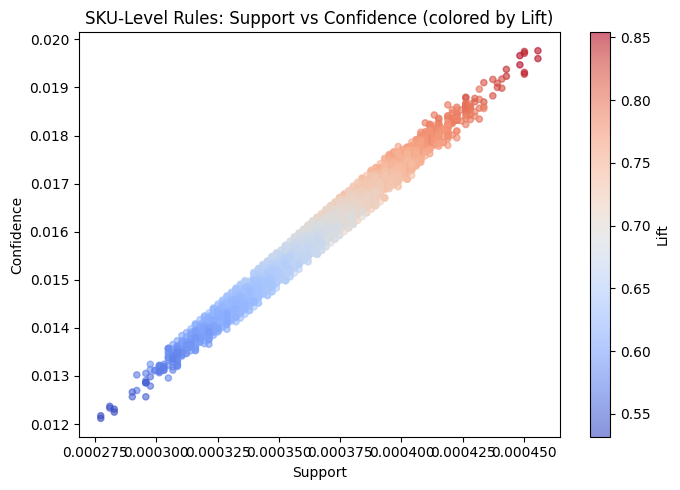

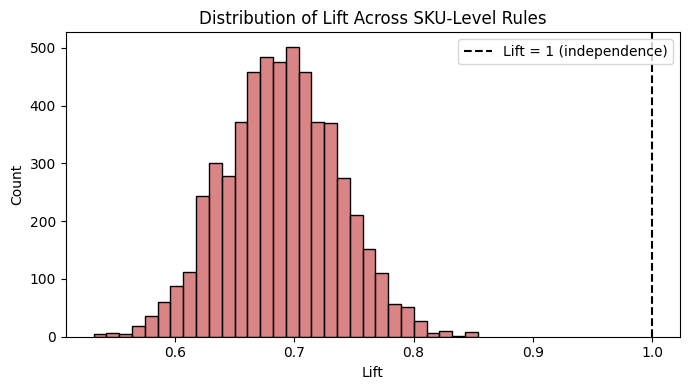

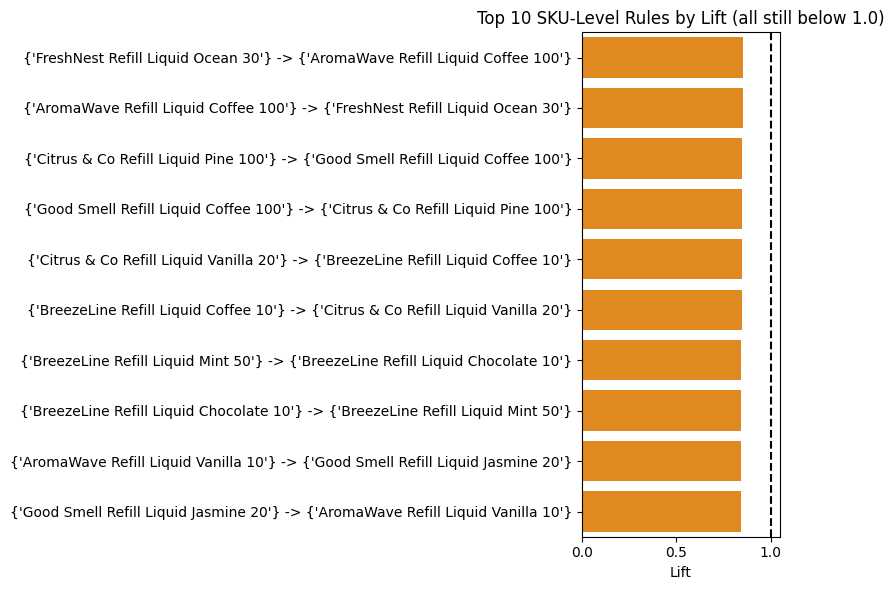

In [ ]:
# 5b. VISUALIZATION - SKU-level rules

# (i) Support vs. Confidence, colored by Lift
plt.figure(figsize=(7, 5))
sc = plt.scatter(rules_sku["support"], rules_sku["confidence"],
                  c=rules_sku["lift"], cmap="coolwarm", alpha=0.6, s=20)
plt.colorbar(sc, label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("SKU-Level Rules: Support vs Confidence (colored by Lift)")
plt.tight_layout()
plt.savefig("arm_sku_support_confidence.png", dpi=150)
plt.show()

# (ii) Distribution of lift across all generated rules
plt.figure(figsize=(7, 4))
sns.histplot(rules_sku["lift"], bins=30, color="indianred")
plt.axvline(1.0, color="black", linestyle="--", label="Lift = 1 (independence)")
plt.title("Distribution of Lift Across SKU-Level Rules")
plt.xlabel("Lift")
plt.legend()
plt.tight_layout()
plt.savefig("arm_sku_lift_distribution.png", dpi=150)
plt.show()

# (iii) Top 10 rules by lift
top10 = rules_sku.head(10).copy()
top10["rule_label"] = top10.apply(
    lambda r: f"{set(r['antecedents'])} -> {set(r['consequents'])}", axis=1
)
plt.figure(figsize=(8, 6))
sns.barplot(x="lift", y="rule_label", data=top10, color="darkorange")
plt.axvline(1.0, color="black", linestyle="--")
plt.title("Top 10 SKU-Level Rules by Lift (all still below 1.0)")
plt.xlabel("Lift")
plt.ylabel("")
plt.tight_layout()
plt.savefig("arm_sku_top10_rules.png", dpi=150)
plt.show()


**Finding:** at SKU granularity, every generated rule has **lift < 1** (max ≈ 0.85, mean ≈ 0.69). No pair of individual products is purchased together more often than random chance would predict - the opposite of a cross-sell signal. This is expected given the basket size (avg. 1.82 items across 98 near-uniformly popular SKUs): most baskets contain a single scent/size variant, so exact-SKU co-occurrence is inherently rare. To check whether affinity exists at a coarser level, the same pipeline was re-run after rolling products up to **brand x category** (5 brands x {Refill Liquid, Accessory/Hardware}).

In [ ]:
# 6. BRAND x CATEGORY ROLL-UP (coarser granularity)
BRANDS = ["AromaDrive", "BreezeLine", "Citrus & Co", "FreshNest", "Good Smell", "AromaWave"]

def parse_brand(name):
    for b in BRANDS:
        if name.startswith(b):
            return b
    return "Other"

def parse_category(name, brand):
    return "Refill Liquid" if name[len(brand):].strip().startswith("Refill Liquid") else "Accessory/Hardware"

unique_products = pd.Series(basket_lists.explode().unique())
brand_map = {p: parse_brand(p) for p in unique_products}
cat_map = {p: parse_category(p, brand_map[p]) for p in unique_products}

def to_tokens(prod_list):
    return list({f"{brand_map[p]} - {cat_map[p]}" for p in prod_list})

basket_tokens = basket_lists.apply(to_tokens)

te2 = TransactionEncoder()
onehot_bc = pd.DataFrame(te2.fit(basket_tokens).transform(basket_tokens), columns=te2.columns_)
print("Brand x Category matrix:", onehot_bc.shape)
print("\nToken support:\n", onehot_bc.mean().sort_values(ascending=False))

freq_bc = fpgrowth(onehot_bc, min_support=0.001, use_colnames=True)
rules_bc = association_rules(freq_bc, metric="lift", min_threshold=1.0)
rules_bc = rules_bc.sort_values("lift", ascending=False).reset_index(drop=True)

print("\nBrand x Category rules with lift > 1:", rules_bc.shape[0])
print(rules_bc[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))

Brand x Category matrix: (544318, 8)

Token support:
 AromaWave - Refill Liquid          0.326482
FreshNest - Refill Liquid          0.308571
Citrus & Co - Refill Liquid        0.307699
BreezeLine - Refill Liquid         0.307475
Good Smell - Refill Liquid         0.290622
BreezeLine - Accessory/Hardware    0.048699
FreshNest - Accessory/Hardware     0.030888
AromaDrive - Accessory/Hardware    0.022702
dtype: float64


**Finding:** even after rolling up to brand/category, the strongest rule found is *(Citrus & Co Refill Liquid + FreshNest Refill Liquid) -> FreshNest Accessory/Hardware* with **lift = 1.05** - a 5% lift over random chance, which is too small to be commercially actionable. Across both granularities, no meaningful complementary-purchase pattern exists in this dataset; customers appear to buy refills largely independently of brand, scent, or accessory line. This is itself a valid, actionable finding (see Business Insights) rather than a modeling failure - the metrics confirm it is stable and not an artifact of the support threshold chosen.


In [ ]:
# 7. EXPORT RESULTS
rules_sku.to_csv("arm_rules_sku_level.csv", index=False)
rules_bc.to_csv("arm_rules_brand_category.csv", index=False)
freq_fpgrowth.to_csv("arm_frequent_itemsets_sku.csv", index=False)
product_counts.to_csv("arm_product_frequency.csv")

print("Done. Files saved:")
print(" - arm_rules_sku_level.csv        (SKU-level association rules)")
print(" - arm_rules_brand_category.csv   (brand x category association rules)")
print(" - arm_frequent_itemsets_sku.csv  (frequent itemsets, SKU level)")
print(" - arm_product_frequency.csv      (individual product purchase counts)")
print(" - arm_basket_size_dist.png, arm_top_products.png")
